In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.utils import show_count_plots #show_outliers,show_count_plots,show_corr
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [55]:
raw_path = r'..\data\raw'
train_path = os.path.join(raw_path,'train.csv')
test_path = os.path.join(raw_path,'test.csv')
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [56]:
train_df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [57]:
train_df.tail()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO
577346,577346,194.633820,-1.307079,21.244353,21.101997,20.809379,20.866345,20.495411,1.101004,A/F,Blue_Cloud,QSO


In [58]:
test_df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [59]:
test_df.tail()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
247430,824777,248.013903,49.533434,21.563545,21.716868,21.670791,21.265478,21.558618,1.214520,A/F,Blue_Cloud
247431,824778,226.823885,52.635936,21.434441,21.075412,20.778300,20.962333,21.010822,1.004950,A/F,Blue_Cloud
247432,824779,232.879335,44.948125,23.294670,22.336583,20.121142,19.405430,18.744581,0.269394,M,Red_Sequence
247433,824780,351.396802,2.451824,20.882944,20.902010,20.222812,20.551737,20.278339,1.199392,G/K,Blue_Cloud
247434,824781,192.793671,35.844331,22.836145,21.790448,20.620442,19.833623,19.399572,0.544832,M,Red_Sequence


In [60]:
print(f'Train Shape Is {train_df.shape}')
print(f'Test Shape Is {test_df.shape}')

Train Shape Is (577347, 12)
Test Shape Is (247435, 11)


In [61]:
train_df.drop('id',inplace=True,axis=1)

In [62]:
for col in train_df.columns[:-3]:
    print(f"{col} Describe: \n{train_df[col].describe()}")
    print("="*40)

alpha Describe: 
count    577347.000000
mean        181.616673
std          96.242941
min           0.011684
25%         132.161499
50%         188.681465
75%         231.829693
max         359.999810
Name: alpha, dtype: float64
delta Describe: 
count    577347.000000
mean         21.834654
std          18.933570
min         -17.966988
25%           2.474097
50%          21.484412
75%          36.988310
max          79.158322
Name: delta, dtype: float64
u Describe: 
count    577347.000000
mean         22.441926
std           2.018135
min          -0.139225
25%          20.977090
50%          22.570222
75%          23.869103
max          28.253263
Name: u, dtype: float64
g Describe: 
count    577347.000000
mean         21.007273
std           1.795426
min          13.535483
25%          19.865005
50%          21.467820
75%          22.292715
max          27.620208
Name: g, dtype: float64
r Describe: 
count    577347.000000
mean         19.962811
std           1.648964
min          12.57

In [63]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  str    
 9   galaxy_population  577347 non-null  str    
 10  class              577347 non-null  str    
dtypes: float64(8), str(3)
memory usage: 58.5 MB


In [64]:
train_df.isna().sum()

alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

In [65]:
train_df['class'].value_counts()

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

In [66]:
train_df['spectral_type'].value_counts()

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

In [67]:
train_df['galaxy_population'].value_counts()

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

In [68]:
sorted(set(train_df['class'].values))

['GALAXY', 'QSO', 'STAR']

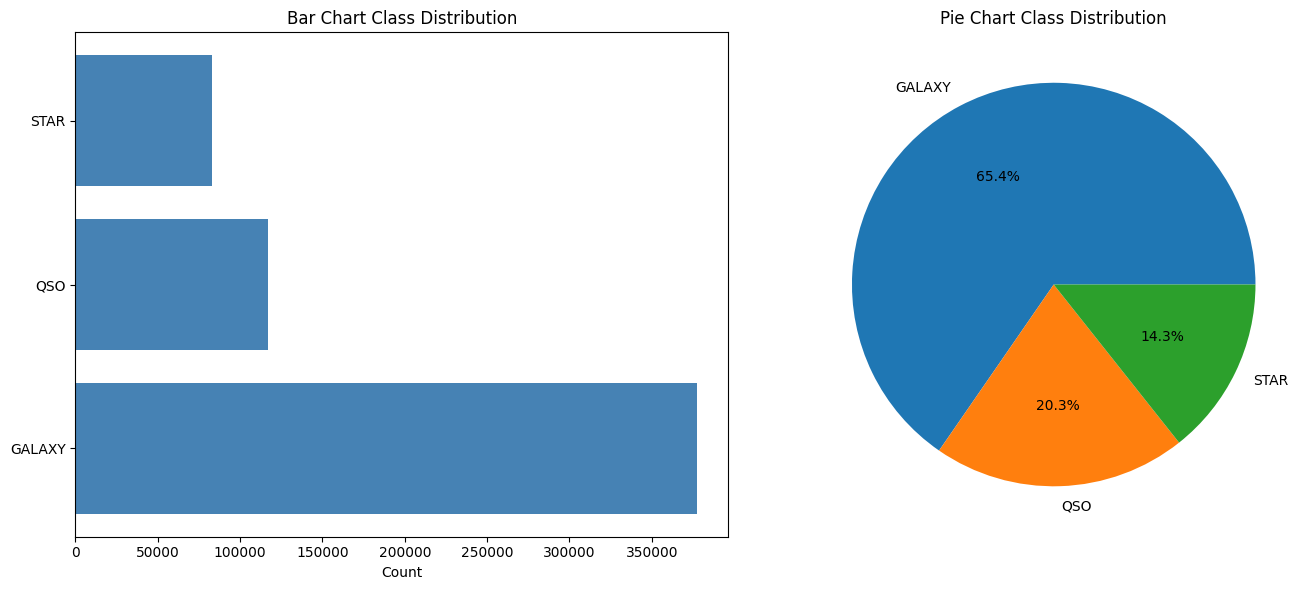

In [69]:
show_count_plots(train_df,'class')

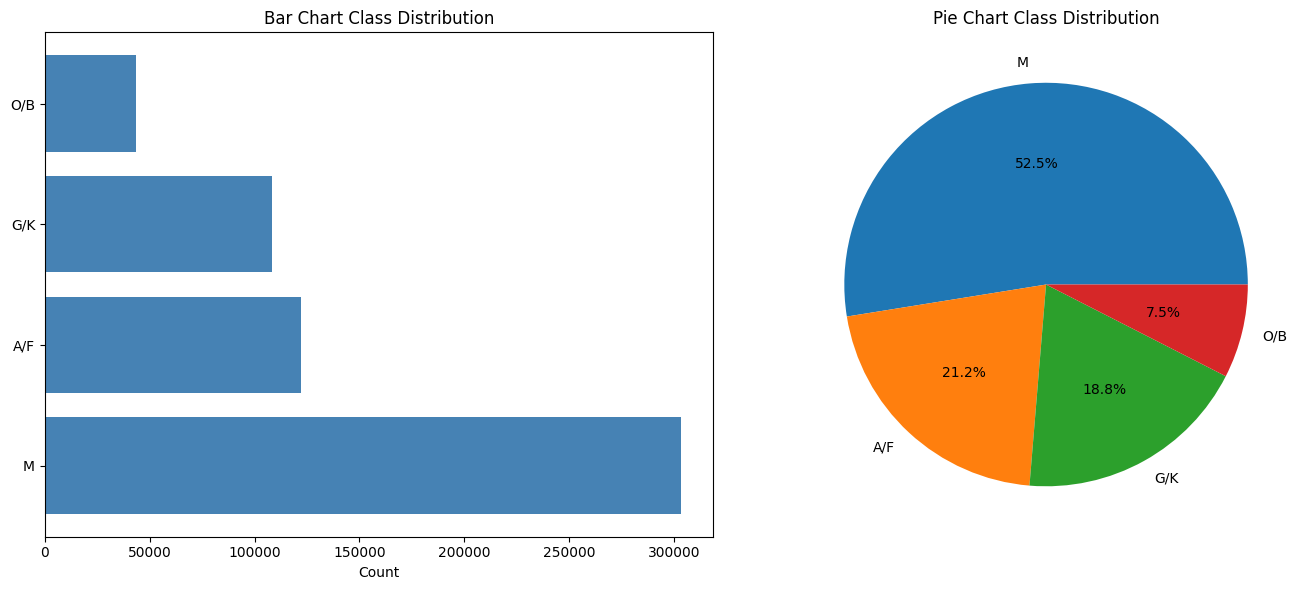

In [70]:
show_count_plots(train_df,'spectral_type')

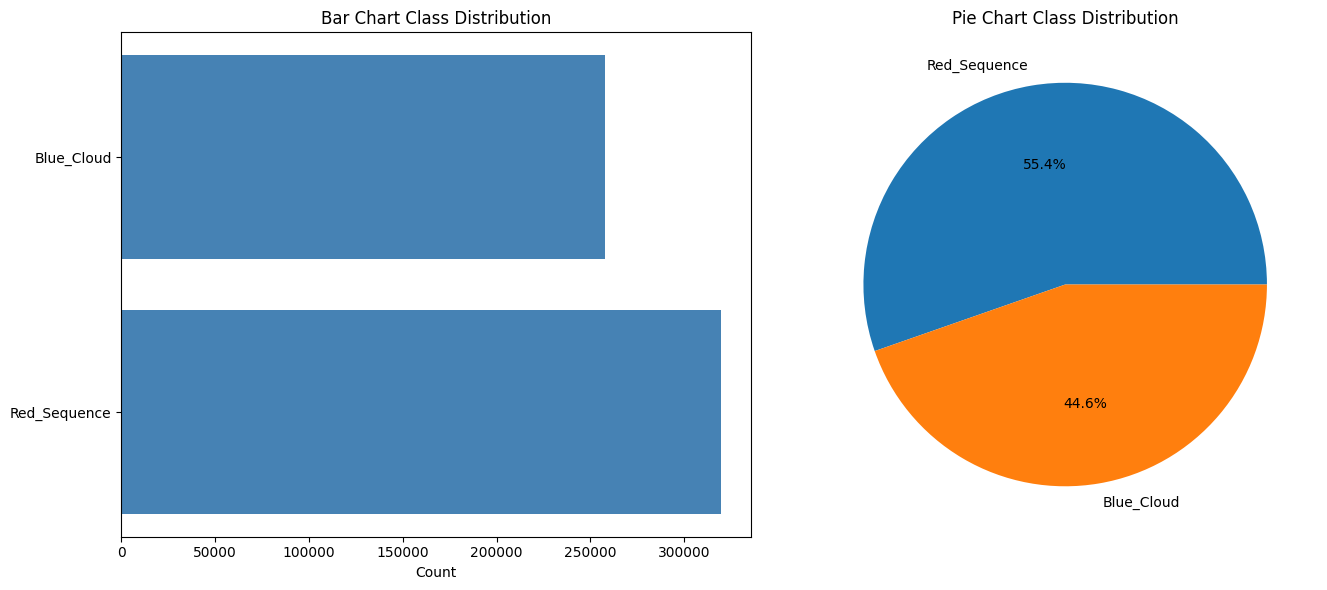

In [71]:
show_count_plots(train_df,'galaxy_population')

In [74]:
train_df_dummies = pd.get_dummies(train_df[train_df.columns[-3:]],dtype=int)
train_df_dummies

,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence,class_GALAXY,class_QSO,class_STAR
0,0,0,1,0,0,1,1,0,0
1,0,0,1,0,0,1,1,0,0
2,0,0,0,1,1,0,0,1,0
3,0,0,1,0,0,1,1,0,0
4,0,0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...
577342,0,0,1,0,0,1,1,0,0
577343,0,0,1,0,0,1,1,0,0
577344,0,0,1,0,0,1,1,0,0
577345,0,1,0,0,1,0,0,1,0


In [75]:
train_df.drop(train_df.columns[-3:],inplace=True,axis=1)

In [ ]:
train_df = pd.concat([train_df,train_df_dummies],axis=1)
train_df

,alpha,delta,u,g,r,i,z,redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence,class_GALAXY,class_QSO,class_STAR
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,1,0,0,1,1,0,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,1,0,0,1,1,0,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,0,0,0,1,1,0,0,1,0
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,1,0,0,1,1,0,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,0,0,1,0,0,1,1,0,0
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,0,0,1,0,0,1,1,0,0
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,0,0,1,0,0,1,1,0,0
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,0,1,0,0,1,0,0,1,0
